# Clustering Jerárquico

In [116]:
from scipy.spatial import distance_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [117]:
## Cargamos los datos

data = pd.read_excel(r"dataset_didactico_machine_learning - ALUMNOS - copia.xlsx")

data.head()

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


<function matplotlib.pyplot.show(close=None, block=None)>

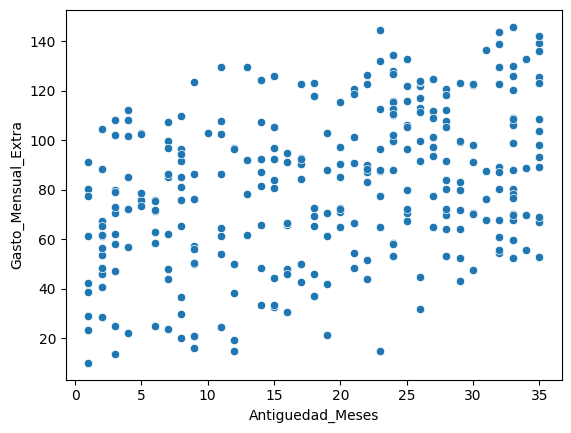

In [118]:
# Visualización con scatter plot
sns.scatterplot(data=data, x="Antiguedad_Meses", y="Gasto_Mensual_Extra")
plt.show

In [119]:
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(data[["Antiguedad_Meses", "Gasto_Mensual_Extra"]])

In [120]:
print("Datos originales:")
print(data [["Antiguedad_Meses", "Gasto_Mensual_Extra"]].head())

Datos originales:
   Antiguedad_Meses  Gasto_Mensual_Extra
0                29            64.161055
1                15            32.554177
2                 8            85.092643
3                21           120.709423
4                19           103.148141


In [121]:
print(f"\nMedia edad: {scaler.mean_[0]:.4f}")
print(f"Sigma edad: {scaler.scale_[0]:.4f}")
print(f"\nMedia salario: {scaler.mean_[1]:.4f}")
print(f"Sigma salario: {scaler.scale_[1]:.4f}")


Media edad: 18.8800
Sigma edad: 10.5855

Media salario: 81.6886
Sigma salario: 30.4170


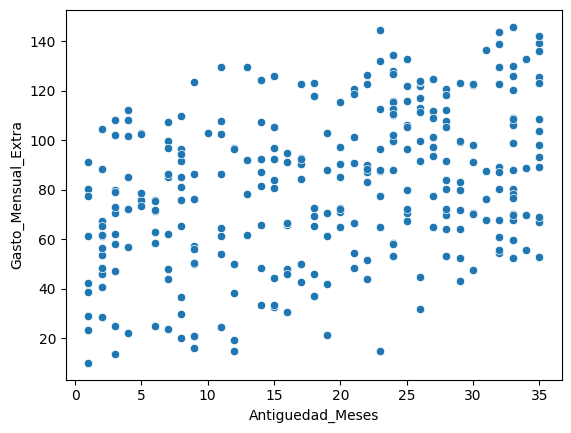

In [122]:
# Visualización con scatter plot
sns.scatterplot(data=data, x="Antiguedad_Meses", y="Gasto_Mensual_Extra")
plt.show()

In [123]:
# Dendograma

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [124]:
z = linkage(
    datos_escalados, 
    method="centroid",
    metric="euclidean")

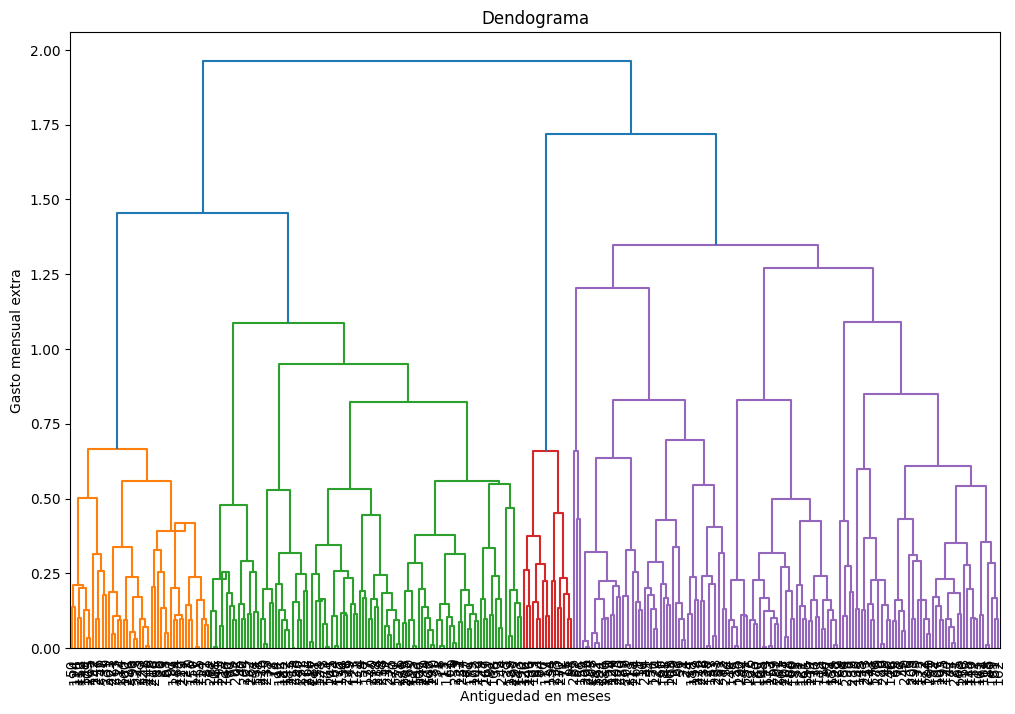

In [125]:
# Calcular la matriz de linkage si no se ha ejecutado la celda anterior
z = linkage(datos_escalados, method="centroid", metric="euclidean")

plt.figure(figsize=(12, 8))
plt.title("Dendograma")
plt.xlabel("Antiguedad en meses")
plt.ylabel("Gasto mensual extra")
dendrogram(z, leaf_rotation=90, leaf_font_size=10)
plt.show()

In [126]:
# Determinar el número optimo de clusters utilizando el método del codo

distancias = z[:, 2]
ultimas_distancias = distancias[:-11:-1]
ultimas_distancias

array([1.96119548, 1.72017101, 1.45286148, 1.34806977, 1.26913544,
       1.20291956, 1.08988862, 1.0861941 , 0.95101176, 0.8482716 ])

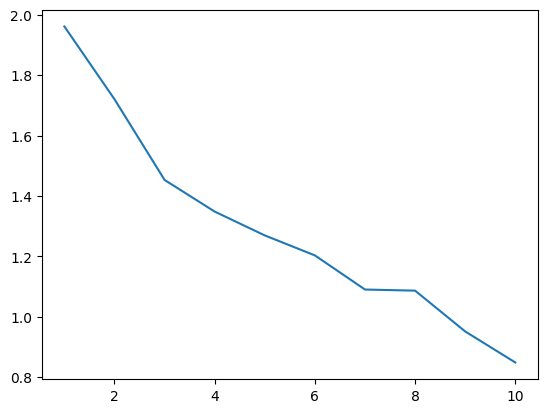

In [127]:
#Visualización del método del codo

sns.lineplot(x=range(1, len(ultimas_distancias) + 1), 
             y=ultimas_distancias
)

plt.show()